## About Dataset


#### Context
It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

#### Content
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.


Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download

In [33]:
#import dependencies 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

In [19]:
# Load the dataset
df = pd.read_csv('../data/creditcard.csv')

In [20]:
# First look
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check the class imbalance

In [21]:
# Count how many fraud vs non-fraud transactions
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Visualize the class distribution

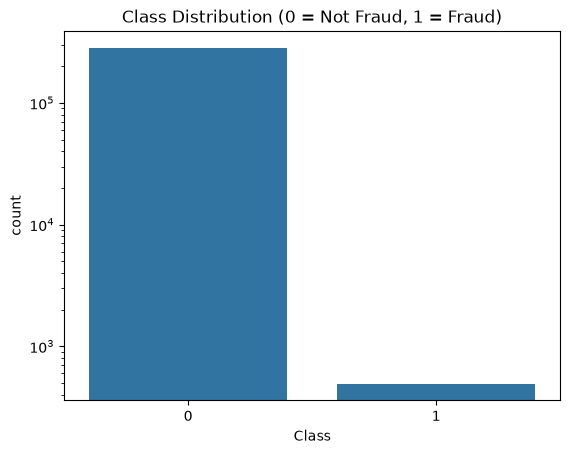

In [22]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Not Fraud, 1 = Fraud)')
plt.yscale('log')  # log scale, otherwise the fraud bar is invisible next to the other one
plt.show()

Explore Amount and Time

In [23]:
# Compare transaction amounts: fraud vs non-fraud
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


BoxPlots:

*Amounts by Class:* fraudulent transactions in this dataset tend to skew toward smaller amounts than legitimate ones. This actually lines up with real-world fraud behavior. Fraudsters often test stolen cards with small transactions first (sometimes called "card testing") to check if the card still works before attempting larger purchases, and small amounts are also less likely to trigger a cardholder's attention or a bank's fraud alert. So Amount does carry some signal — not a clean separation, but a noticeable shift in distribution.

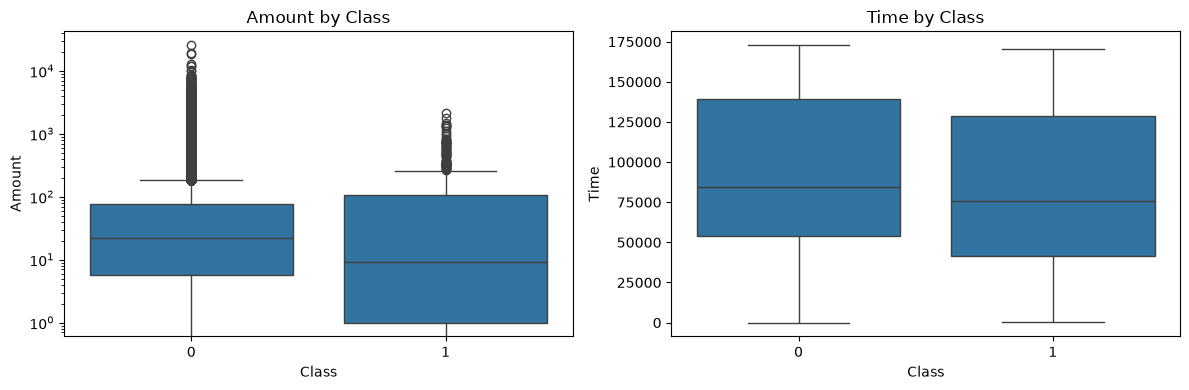

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_title('Amount by Class')
axes[0].set_yscale('log')  # amounts vary hugely, log scale keeps it readable

sns.boxplot(x='Class', y='Time', data=df, ax=axes[1])
axes[1].set_title('Time by Class')

plt.tight_layout()
plt.show()

 Preparing the data for modeling  -- Split data into train and test Split

In [25]:
# Features (X) = everything except the target
X = df.drop('Class', axis=1)

# Target (y) = what we're predicting
y = df['Class']

# Split into train and test sets, stratified on y
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print(f"Fraud cases in train: {y_train.sum()}")
print(f"Fraud cases in test: {y_test.sum()}")

Training set: 227845 rows
Test set: 56962 rows
Fraud cases in train: 394
Fraud cases in test: 98


Now, scaling the data: transforms values so they have a mean of 0 and standard deviation of 1.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on training data only, then apply to both
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

X_train[['Amount', 'Time']].describe()

,Amount,Time
count,2.278450e+05,2.278450e+05
mean,3.742243e-17,-1.409578e-16
std,1.000002e+00,1.000002e+00
min,-3.516894e-01,-1.998073e+00
25%,-3.291944e-01,-8.561495e-01
50%,-2.639429e-01,-2.122647e-01
75%,-4.262209e-02,9.366285e-01
max,1.021170e+02,1.640549e+00


#### Training the Model:

1) Logistic Regression (baseline)

In [27]:
# class_weight='balanced' tells the model to pay more attention to the minority class (fraud)
model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

model_lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Evaluate the Model:

In [28]:


y_pred_lr = model_lr.predict(X_test)

print(confusion_matrix(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

[[55478  1386]
 [    8    90]]

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



55,478 legitimate transactions correctly identified as legitimate 

1,386 legitimate transactions wrongly flagged as fraud (false positives)

8 actual fraud cases the model missed entirely, let through as "not fraud" (false negatives — the dangerous ones)

90 actual fraud cases correctly caught

#### Why accuracy (98%) is misleading here

98% sounds great, but remember: even a model that predicts nothing is ever fraud would score 99.8% accuracy on this dataset, because fraud is so rare. Accuracy barely moves even when a model is catching almost no fraud, because it's dominated by the huge number of easy, correct "not fraud" predictions. This is exactly the trap I flagged earlier, this is why we look at precision and recall instead.
Precision vs Recall — the real story


#### For Class 1 (fraud):

*Recall = 0.92* → of all 98 actual fraud cases in the test set, the model correctly caught 90 of them (92%). Only 8 slipped through. That's strong, in fraud detection, missing real fraud is usually the costliest mistake (direct financial loss, regulatory exposure), so high recall is often the priority.

*Precision = 0.06* → of everything the model flagged as fraud (1,476 transactions total: 90 real + 1,386 false alarms), only 6% were actually fraud. That's very weak. In practice this means: for every real fraud case caught, roughly 15 innocent customers get their legitimate transaction flagged/blocked.

#### The trade-off this reveals

This model is heavily biased toward *"catch fraud at almost any cost"* — a direct consequence of class_weight='balanced' telling it that missing fraud is expensive. That's a reasonable stance for a first pass, but in a real fintech deployment, 1,386 false alarms out of ~56,864 legitimate transactions (~2.4%) would mean a lot of annoyed customers getting declined or flagged unnecessarily; a real business cost (customer trust, support calls, lost revenue from blocked legit purchases).


This precision/recall trade-off is the central tension in fraud detection, and there's no universally "correct" balance,  it depends on the bank's risk appetite and cost structure (cost of a missed fraud vs. cost of annoying a legitimate customer).

2. Random Forest

In [29]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

Evaluate the Model:

In [30]:
y_pred_rf = model_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

[[56856     8]
 [   21    77]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



The random forest is a massive improvement in precision — from 6% up to 91%. Remember what precision measures: of everything flagged as fraud, how much actually was fraud? Logistic regression cried wolf 1,386 times; random forest only cried wolf 8 times. That's a huge reduction in innocent customers getting flagged.

#### But it came at a cost: 
recall dropped from 92% to 79%. The random forest now misses 21 fraud cases instead of 8. It's more cautious about calling something fraud, which means fewer false alarms, but also means some real fraud slips through that the logistic regression model would have caught.

*F1-score* (the balance between precision and recall) tells the summary story: 0.11 for logistic regression vs. 0.84 for random forest. By that combined measure, random forest is clearly the stronger model overall.

#### Which one is actually "better"?
This is where data science meets business reality — there's no purely mathematical answer. It depends on what a company would care about more:

If the cost of missing fraud is catastrophic (large financial loss, regulatory penalty) → logistic regression's higher recall might be worth tolerating more false alarms.
If the cost of false positives is the bigger concern (blocked legitimate transactions, customer churn, support costs, damaged trust) → random forest's much higher precision wins clearly.

In practice, most fraud teams lean toward something closer to the random forest's profile — a small number of very confident flags that a human reviewer can actually investigate, rather than 1,386 alerts a day that overwhelm the fraud team and get ignored. This is actually a real, well-known phenomenon in fraud ops called *alert fatigue*.

Precision-Recall Curve

In [34]:
# Get predicted probabilities instead of hard 0/1 predictions
y_scores_rf = model_rf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores_rf)
avg_precision = average_precision_score(y_test, y_scores_rf)

print(f"Average Precision (AP) score: {avg_precision:.3f}")

Average Precision (AP) score: 0.863


Plot the Result:

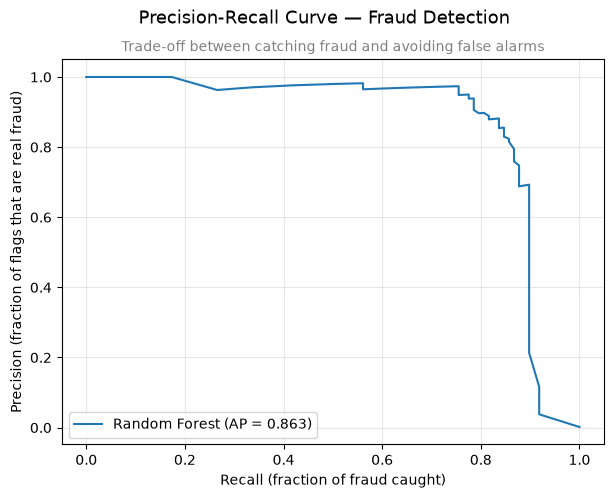

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'Random Forest (AP = {avg_precision:.3f})')
plt.xlabel('Recall (fraction of fraud caught)')
plt.ylabel('Precision (fraction of flags that are real fraud)')
plt.suptitle('Precision-Recall Curve — Fraud Detection', fontsize=13, y=0.98)
plt.title('Trade-off between catching fraud and avoiding false alarms', fontsize=10, color='gray')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Precision-Recall Curve

Unlike the confusion matrix (which reflects a single fixed threshold of 0.5), this curve shows 
model performance across **every possible decision threshold**. 

- **Recall (x-axis)**: what fraction of actual fraud cases the model catches
- **Precision (y-axis)**: of everything flagged as fraud, what fraction is genuinely fraud

As the threshold is lowered to catch more fraud (higher recall), precision typically drops, since 
the model starts flagging more borderline/ambiguous transactions. The **Average Precision (AP)** 
score summarizes this trade-off into a single number — 1.0 is perfect, and a random guess on this 
imbalanced dataset would score close to 0.0017 (the actual fraud rate).

 #### Feature Importance

Even though V1–V28 are anonymized, we can still see which features the random forest leaned on most when making decisions.

In [31]:
# Pull feature importances out of the trained random forest
importances = pd.Series(model_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

importances.head(10)

V14    0.191038
V10    0.106849
V4     0.105643
V12    0.097603
V17    0.090339
V3     0.065919
V11    0.046342
V16    0.044655
V2     0.038335
V9     0.025445
dtype: float64

Now let's visualize the top 10:

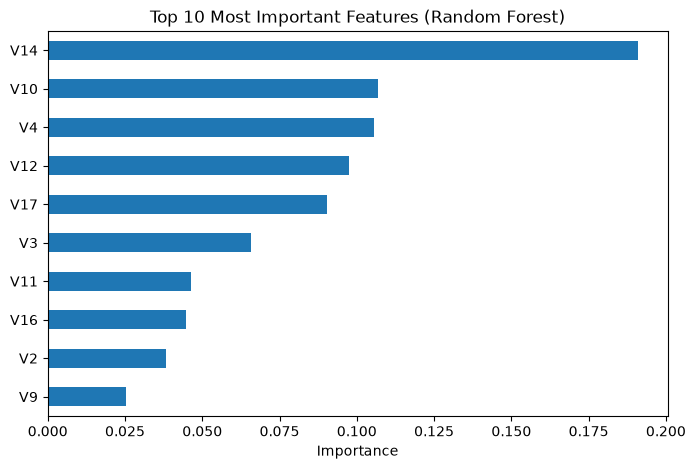

In [32]:
top10 = importances.head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.show()

#### Worth noting: 
Amount and Time didn't make the top 10. That's not a contradiction,  it just means the PCA components captured that same distinguishing information (and more) more efficiently than the raw amount value did on its own. 